In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, roc_auc_score
import os

In [22]:
my_data = pd.read_excel(r'C:\Users\dell\Documents\Customer Churn Analysis & Prediction\data_set\Telco_customer_churn.xlsx')
my_data.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [23]:
# Check column types 
my_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [24]:
# Quick statistics on numeric columns
my_data.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [25]:
# Drop ID column

my_data.drop(columns='CustomerID', inplace = True) 

# Check the shape
print(f"Modeling dataset shape: {my_data.shape}")

Modeling dataset shape: (7043, 32)


In [26]:
# Rename columns

new_columns = my_data.columns.str.replace(' ', '')
my_data.columns = new_columns

Exploratory Data Analysis


In [27]:
# Count missing values
my_data.isnull().sum()

Count                  0
Country                0
State                  0
City                   0
ZipCode                0
LatLong                0
Latitude               0
Longitude              0
Gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
TenureMonths           0
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
ChurnLabel             0
ChurnValue             0
ChurnScore             0
CLTV                   0
ChurnReason         5174
dtype: int64

In [28]:
# Check target variable
my_data['ChurnLabel'].value_counts()

ChurnLabel
No     5174
Yes    1869
Name: count, dtype: int64

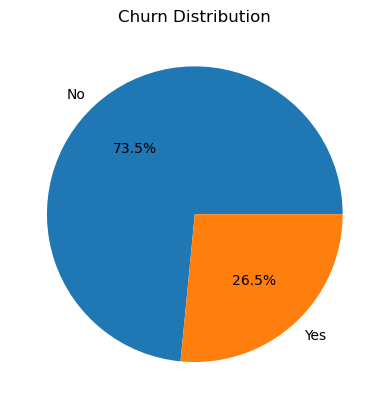

In [29]:
import matplotlib.pyplot as plt 
# Count values
counts = my_data['ChurnLabel'].value_counts()

# Labels (Yes / No)
labels = counts.index

# Plot pie chart
plt.pie(counts, labels=labels, autopct='%1.1f%%')

plt.title('Churn Distribution')
plt.show()

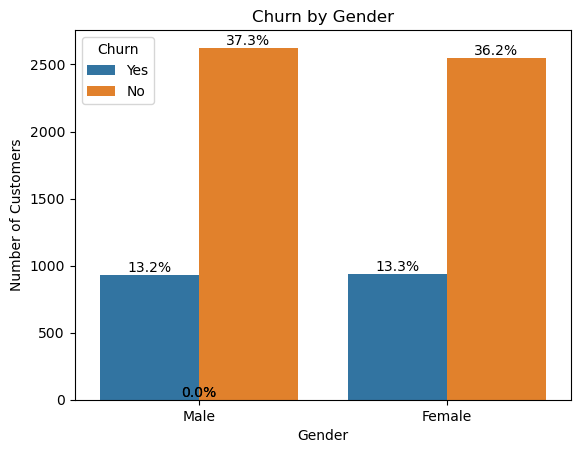

In [30]:
import seaborn as sns
total = len(my_data)

ax = sns.countplot(x='Gender', hue='ChurnLabel', data=my_data)

# Annotate bars with percentages
for p in ax.patches:
    percentage = 100 * p.get_height() / total
    ax.annotate(f'{percentage:.1f}%', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.title('Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.show()

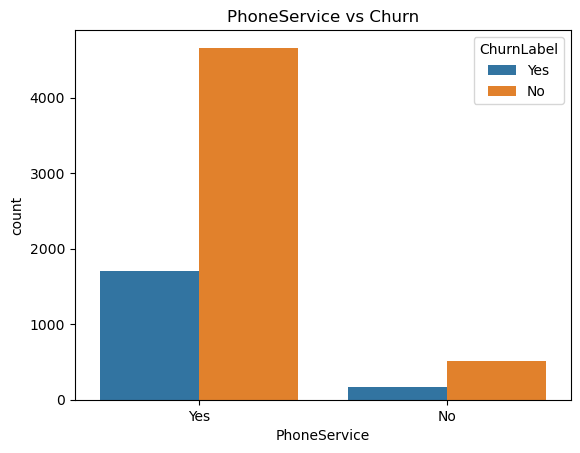

Most customers have phone service.



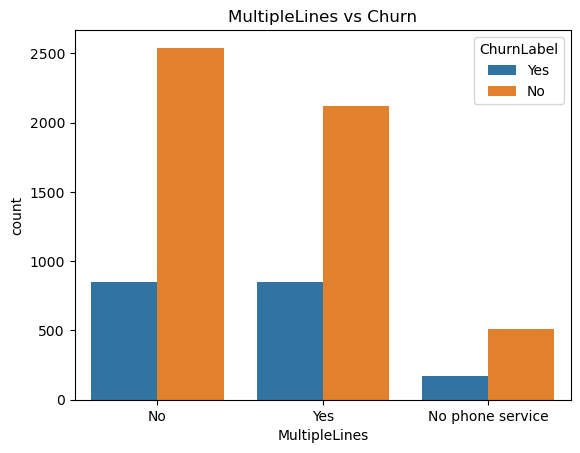

Customers without multiple lines have slightly lower churn.



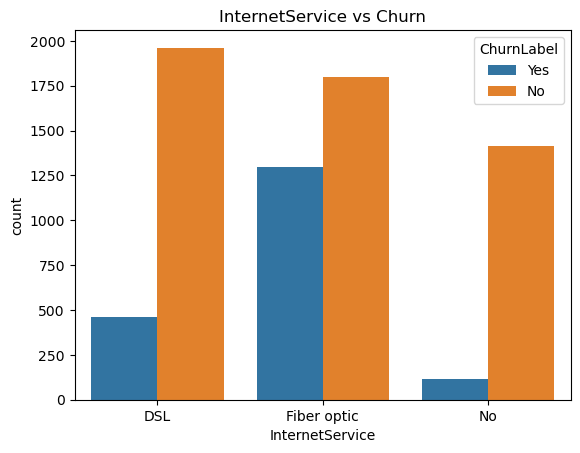

Fiber optic users tend to churn more; no internet service rarely churns.



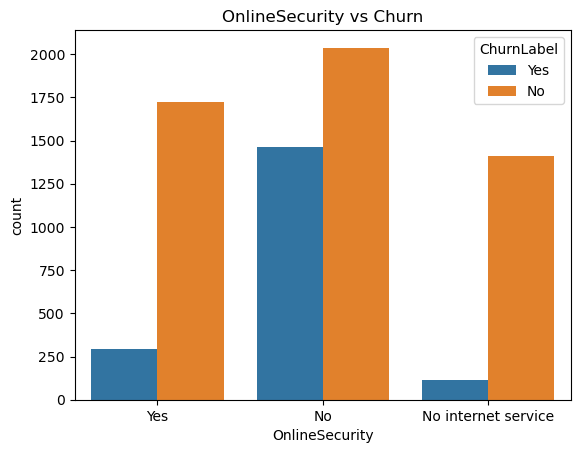

Customers without online security show higher churn.



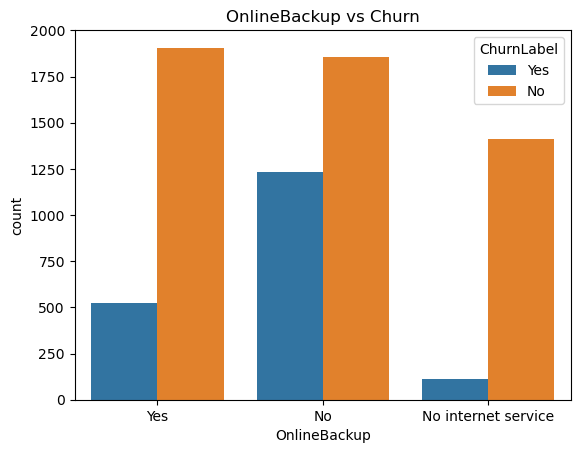

Customers without online backup churn more; backup helps retention.



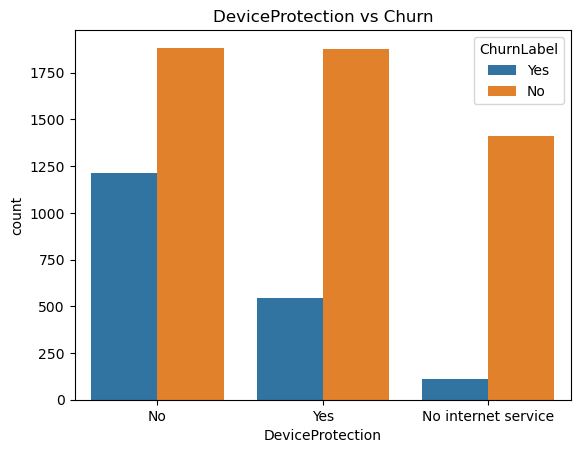

Lacking device protection correlates with higher churn.



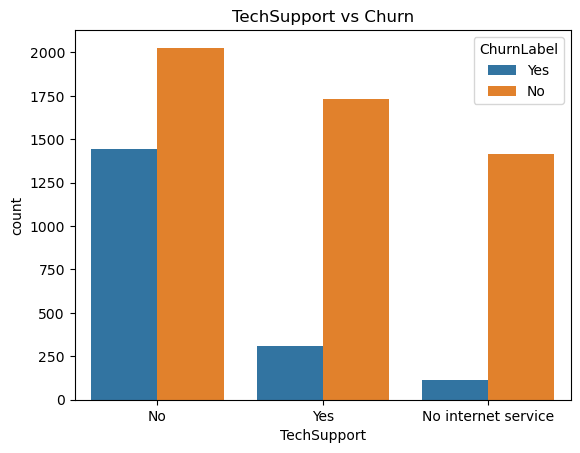

No tech support is strongly linked to higher churn.



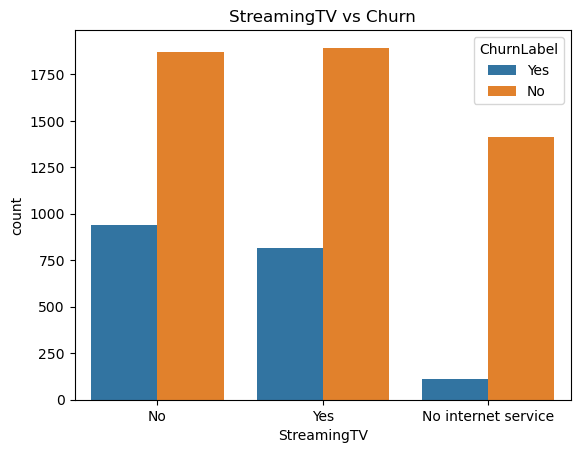

Streaming TV may slightly decrease churn.



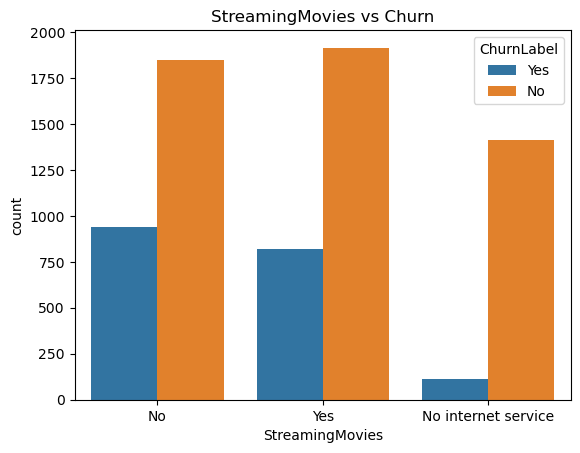

Similar to streaming TV, streaming movies have a small effect on churn.



In [31]:
service_cols = ['PhoneService', 'MultipleLines', 'InternetService',
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']


# Dictionary of comments for each column
comments = {
    'PhoneService': "Most customers have phone service.",
    'MultipleLines': "Customers without multiple lines have slightly lower churn.",
    'InternetService': "Fiber optic users tend to churn more; no internet service rarely churns.",
    'OnlineSecurity': "Customers without online security show higher churn.",
    'OnlineBackup': "Customers without online backup churn more; backup helps retention.",
    'DeviceProtection': "Lacking device protection correlates with higher churn.",
    'TechSupport': "No tech support is strongly linked to higher churn.",
    'StreamingTV': "Streaming TV may slightly decrease churn.",
    'StreamingMovies': "Similar to streaming TV, streaming movies have a small effect on churn."
}

# Loop through columns and plot
for col in service_cols:
    ax = sns.countplot(x=col, hue='ChurnLabel', data=my_data)
    plt.title(f"{col} vs Churn")
    
    # Show the plot
    plt.show()
    
    # Print the comment under the plot
    #print(f"Comment for {col}: {comments[col]}\n")
    print(f"{comments[col]}\n")

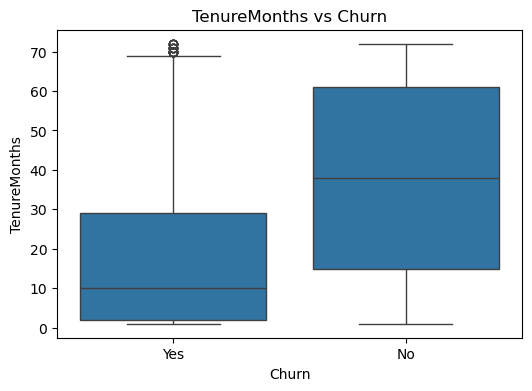

Customers with shorter tenure are more likely to churn. Longer-tenured customers tend to stay, showing that loyalty increases over time.



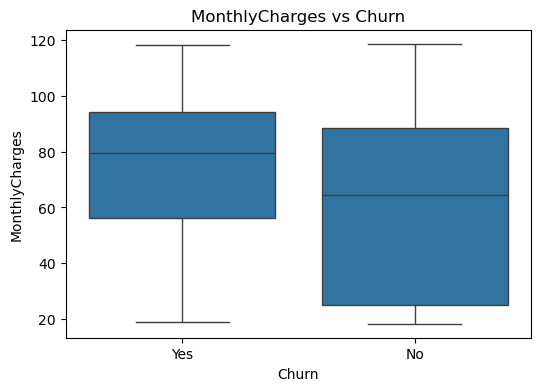

Customers with higher monthly charges show a slightly higher churn rate. Low-to-mid charges are associated with more retained customers.



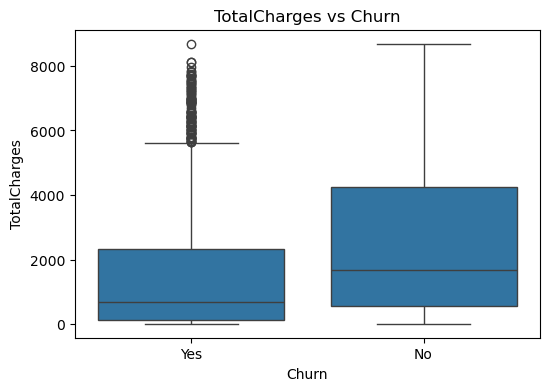

Customers with low total charges tend to churn more, usually because they are newer customers. High total charges often indicate long-term customers who are less likely to churn.



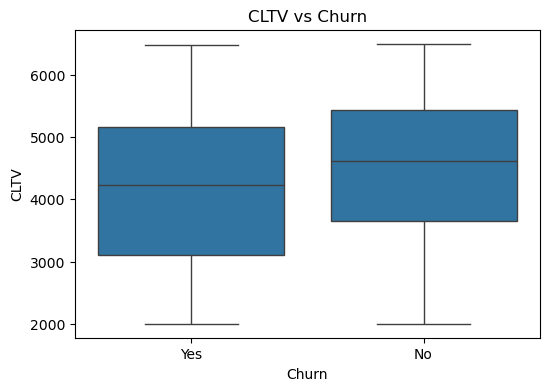

Customers with low CLTV are more likely to churn. Higher CLTV correlates with retention, suggesting these customers are more valuable and loyal.



In [32]:
 #Ensure numeric columns are truly numeric
numeric_cols = ['TenureMonths','MonthlyCharges','TotalCharges','CLTV']

for col in numeric_cols:
    my_data[col] = pd.to_numeric(my_data[col], errors='coerce')

# Optional: drop rows with missing values for these columns
my_data_clean = my_data.dropna(subset=numeric_cols)

numeric_comments = { 'TenureMonths': "Customers with shorter tenure are more likely to churn. Longer-tenured customers tend to stay, showing that loyalty increases over time.", 
                    'MonthlyCharges': "Customers with higher monthly charges show a slightly higher churn rate. Low-to-mid charges are associated with more retained customers.",
                    'TotalCharges': "Customers with low total charges tend to churn more, usually because they are newer customers. High total charges often indicate long-term customers who are less likely to churn.", 
                    'CLTV': "Customers with low CLTV are more likely to churn. Higher CLTV correlates with retention, suggesting these customers are more valuable and loyal." }

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='ChurnLabel', y=col, data=my_data_clean)
    plt.title(f"{col} vs Churn")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.show()
    
    print(f"{numeric_comments[col]}\n")

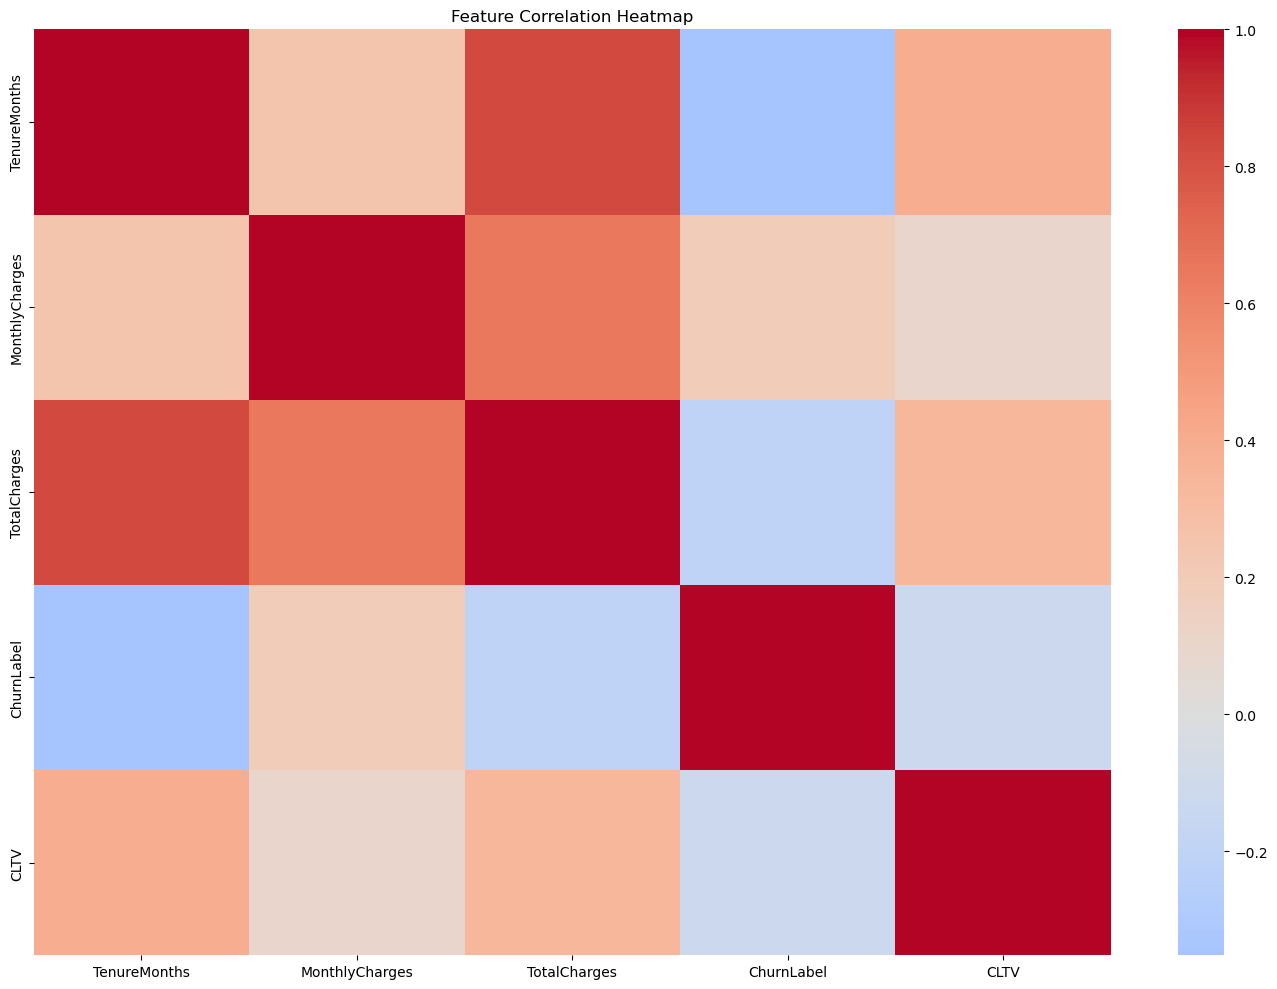

In [33]:
# Correlation Heatmap (excluding geographic and leakage columns)
exclude_cols = ['Count','Country','State','City','ZipCode','LatLong','Latitude','Longitude','ChurnValue','ChurnScore']
heatmap_data = my_data.drop(columns=[c for c in exclude_cols if c in my_data.columns])

# Convert ChurnLabel to numeric for correlation
heatmap_data['ChurnLabel'] = heatmap_data['ChurnLabel'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_data.corr(numeric_only=True), annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [34]:
# Drop unimportant columns

# Drop geographic columns 
drop_cols = ['Count','Country','State','City','ZipCode','LatLong','Latitude','Longitude']
my_data.drop(columns=drop_cols, inplace = True)

# Drop ChurnValue and ChurnScore as they are derived from the target variable (ChurnLabel),
# Keeping them would cause data leakage and give the model the answer directly.

my_data.drop(columns = ['ChurnValue', 'ChurnScore'], inplace = True)

# Check the shape
print(my_data.shape)

(7043, 22)


In [35]:
# Handle missing or inconsistent values

# 'Total Charges' and 'Monthly Charges'may have blank strings → convert to numeric; invalid parsing becomes NaN
cols_to_numeric = ['TotalCharges', 'MonthlyCharges']
my_data[cols_to_numeric] = my_data[cols_to_numeric].apply(pd.to_numeric, errors='coerce')

my_data.isnull().sum()

Gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
TenureMonths           0
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges          11
ChurnLabel             0
CLTV                   0
ChurnReason         5174
dtype: int64

In [36]:
# remove Churn Reason columns as it contains 73% of missing values
my_data.drop(columns = 'ChurnReason', inplace = True)

# Drop rows with missing Total Charges
my_data = my_data.dropna()

# Confirm no missing values
#print("Missing values per column after cleaning:")
print(my_data.isnull().sum())

Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
TenureMonths        0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
ChurnLabel          0
CLTV                0
dtype: int64


In [37]:
# Encode binary categorical variables

my_data = my_data.copy()

binary_cols = ['Gender','SeniorCitizen','Partner','Dependents','PhoneService','PaperlessBilling','ChurnLabel',
'MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']


for col in binary_cols:
    my_data[col] = my_data[col].replace({
        'Yes':1, 'No':0,
        'Male':1, 'Female':0,
        'No internet service':0,
        'No phone service':0
    })

# Quick check
my_data[binary_cols].head()

C:\Users\dell\AppData\Local\Temp\ipykernel_9628\4017453565.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_data[col] = my_data[col].replace({


,Gender,SeniorCitizen,Partner,Dependents,PhoneService,PaperlessBilling,ChurnLabel,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,1,0,0,0,1,1,1,0,1,1,0,0,0,0
1,0,0,0,1,1,1,1,0,0,0,0,0,0,0
2,0,0,0,1,1,1,1,1,0,0,1,0,1,1
3,0,0,1,1,1,1,1,1,0,0,1,1,1,1
4,1,0,0,1,1,1,1,1,0,1,1,0,1,1


In [ ]:

#Scale numeric features

scaler = StandardScaler()
scale_cols = ['TenureMonths','MonthlyCharges','TotalCharges','CLTV']

my_data[scale_cols] = scaler.fit_transform(my_data[numeric_cols])

# Quick check
my_data[scale_cols].head()

,TenureMonths,MonthlyCharges,TotalCharges,CLTV
0,-1.239504,-0.363923,-0.959649,-0.983181
1,-1.239504,0.196178,-0.940457,-1.438215
2,-0.995040,1.158489,-0.645369,0.820883
3,-0.180161,1.329677,0.336516,0.508788
4,0.675462,1.293113,1.214589,0.793818


In [ ]:
#One-hot encode multi-category columns

multi_cat_cols = ['InternetService','Contract','PaymentMethod']

my_data = pd.get_dummies(my_data, columns=multi_cat_cols, drop_first=True)

# Verify all columns are numeric
my_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   TenureMonths                           7032 non-null   float64
 5   PhoneService                           7032 non-null   int64  
 6   MultipleLines                          7032 non-null   int64  
 7   OnlineSecurity                         7032 non-null   int64  
 8   OnlineBackup                           7032 non-null   int64  
 9   DeviceProtection                       7032 non-null   int64  
 10  TechSupport                            7032 non-null   int64  
 11  Streaming

In [42]:
# Convert boolean columns to int
bool_cols = my_data.select_dtypes(include='bool').columns
my_data[bool_cols] = my_data[bool_cols].astype(int)

# Check
with pd.option_context('display.max_columns', None):  # None = show all columns
    display(my_data.head(5))

,Gender,SeniorCitizen,Partner,Dependents,TenureMonths,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,ChurnLabel,CLTV,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,0,0,-1.239504,1,0,1,1,0,0,0,0,1,-0.363923,-0.959649,1,-0.983181,0,0,0,0,0,0,1
1,0,0,0,1,-1.239504,1,0,0,0,0,0,0,0,1,0.196178,-0.940457,1,-1.438215,1,0,0,0,0,1,0
2,0,0,0,1,-0.995040,1,1,0,0,1,0,1,1,1,1.158489,-0.645369,1,0.820883,1,0,0,0,0,1,0
3,0,0,1,1,-0.180161,1,1,0,0,1,1,1,1,1,1.329677,0.336516,1,0.508788,1,0,0,0,0,1,0
4,1,0,0,1,0.675462,1,1,0,1,1,0,1,1,1,1.293113,1.214589,1,0.793818,1,0,0,0,0,0,0


In [43]:
my_data.head()

,Gender,SeniorCitizen,Partner,Dependents,TenureMonths,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,TotalCharges,ChurnLabel,CLTV,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,0,0,-1.239504,1,0,1,1,0,...,-0.959649,1,-0.983181,0,0,0,0,0,0,1
1,0,0,0,1,-1.239504,1,0,0,0,0,...,-0.940457,1,-1.438215,1,0,0,0,0,1,0
2,0,0,0,1,-0.995040,1,1,0,0,1,...,-0.645369,1,0.820883,1,0,0,0,0,1,0
3,0,0,1,1,-0.180161,1,1,0,0,1,...,0.336516,1,0.508788,1,0,0,0,0,1,0
4,1,0,0,1,0.675462,1,1,0,1,1,...,1.214589,1,0.793818,1,0,0,0,0,0,0


In [45]:
# Define features and target

X = my_data.drop(['ChurnLabel'], axis=1)
y = my_data['ChurnLabel']

# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)

Accuracy: 0.8088130774697939
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1033
           1       0.65      0.61      0.63       374

    accuracy                           0.81      1407
   macro avg       0.76      0.74      0.75      1407
weighted avg       0.81      0.81      0.81      1407

[[911 122]
 [147 227]]


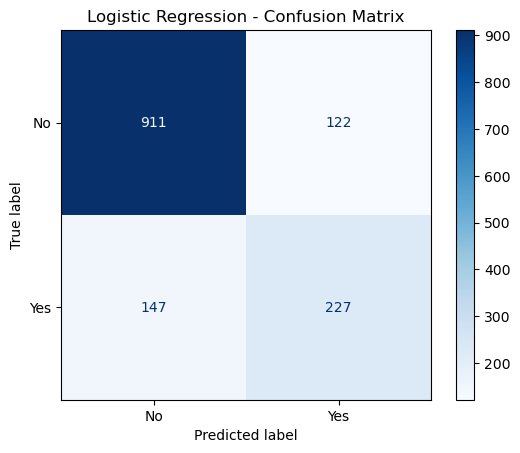

In [46]:
# Train the model

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict

y_pred = model.predict(X_test)

# Evaluate

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


# Logistic Regression Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No', 'Yes'], cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

The model shows strong specificity (88.2%) but weak recall (60.7%), indicating a negative bias. It correctly identifies 911 non-cases but misses 147 positive cases. Accuracy is ~81%, but this masks class imbalance. Recommend adjusting decision threshold, using class weights, or applying SMOTE to improve recall on the minority class.